Filename: hst_11602_02_wfc3_uvis_f814w_ib4802_drc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1000   ()      
  1  SCI           1 ImageHDU       100   (4291, 4650)   float32   
  2  WHT           1 ImageHDU        45   (4291, 4650)   float32   
  3  CTX           1 ImageHDU        40   (4291, 4650)   int32   
  4  HDRTAB        1 BinTableHDU    564   12R x 277C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 9A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, 8A, 23A, D, D, D, D, K, K, 8A, 23A, 9A, 19A, 4A, K, D, D, D, K, K, K, K, 23A, D, D, D, D, K, K, 4A, 3A, 4A, L, D, D, D, 23A, 1A, K, D, D, D, 4A, 1A, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 4A, 3A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, 8A, D, D, 4A, 46A, 3A, K, 5A, 4A, D, 13A, 8A, 4A, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, D, 3A, K, D, 5A, 7A, D, D, D, D, D, D, D, D, D

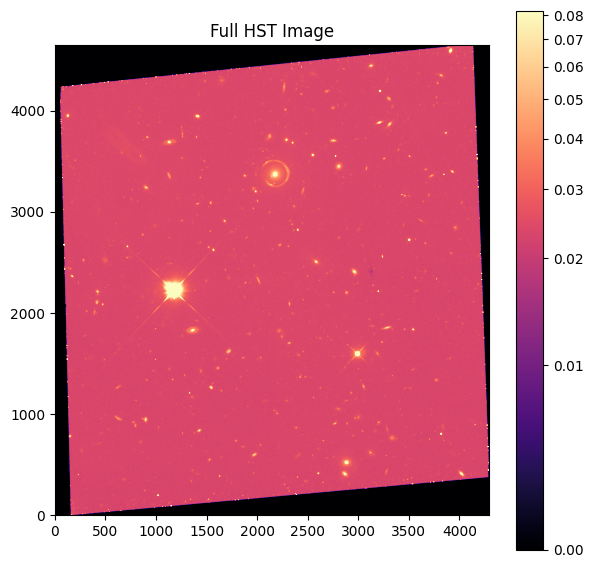

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import simple_norm

from scipy.ndimage import gaussian_filter
from skimage.filters import sobel

# =============================
# 1. LOAD FITS FILE 
# =============================
filename = "hst_11602_02_wfc3_uvis_f814w_ib4802_drc.fits"

hdul = fits.open(filename)
hdul.info()

# find correct image HDU
data = None
for i in range(len(hdul)):
    if hdul[i].data is not None:
        print(f"Using HDU {i}")
        data = hdul[i].data
        break

if data is None:
    raise ValueError("No valid image found!")

# handle multi-channel
if data.ndim == 3:
    data = data[0]

# clean NaNs
data = np.nan_to_num(data)

# print("Data shape:", data.shape)

# =============================
# 2. VISUALIZATION
# =============================
norm = simple_norm(data, 'asinh', percent=99.7)

plt.figure(figsize=(7,7))
plt.imshow(data, cmap='magma', origin='lower', norm=norm)
plt.title("Full HST Image")
plt.colorbar()
plt.show()

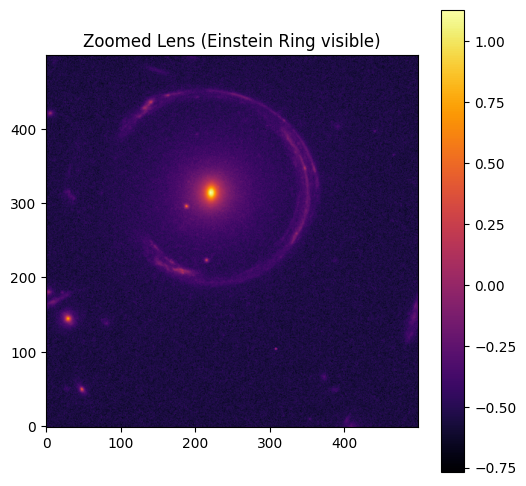

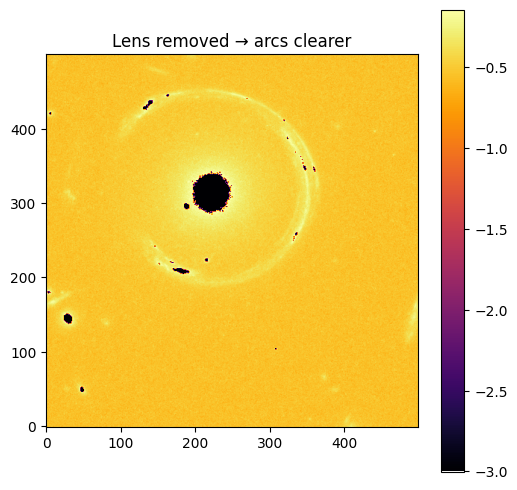

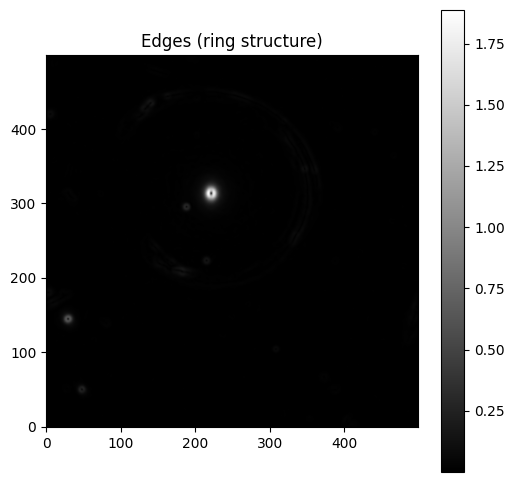

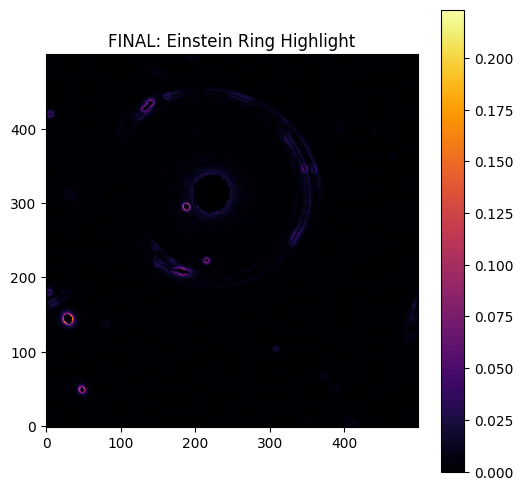

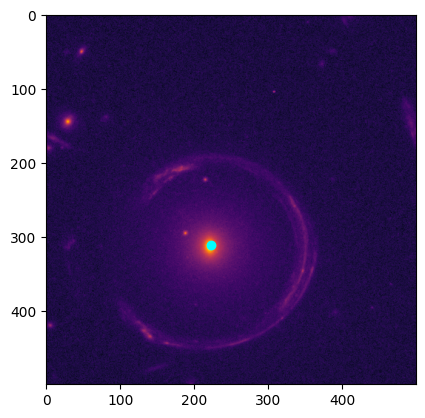

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from skimage.filters import sobel

# =============================
# 1. MANUAL CENTER
# =============================
x0, y0 = 2200, 3300 

size = 500
half = size // 2

cutout = data[y0-half:y0+half, x0-half:x0+half]

# normalize
cutout = cutout / (np.percentile(cutout, 99.5) + 1e-6)

# =============================
# 2. SHOW LENS REGION
# =============================
plt.figure(figsize=(6,6))
plt.imshow(np.log10(cutout + 1e-3), cmap='inferno', origin='lower')
plt.title("Zoomed Lens (Einstein Ring visible)")
plt.colorbar()
plt.show()

# =============================
# 3. REMOVE CENTRAL GALAXY
# =============================
clean = cutout.copy()

# remove brightest region (lens core)
clean[clean > np.percentile(clean, 99)] = 0

plt.figure(figsize=(6,6))
plt.imshow(np.log10(clean + 1e-3), cmap='inferno', origin='lower')
plt.title("Lens removed → arcs clearer")
plt.colorbar()
plt.show()

# =============================
# 4. EDGE DETECTION
# =============================
smooth = gaussian_filter(cutout, sigma=2)
edges = sobel(smooth)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray', origin='lower')
plt.title("Edges (ring structure)")
plt.colorbar()
plt.show()

# =============================
# 5. FINAL ARC MAP 
# =============================
combined = edges * clean

plt.figure(figsize=(6,6))
plt.imshow(combined, cmap='inferno', origin='lower')
plt.title("FINAL: Einstein Ring Highlight")
plt.colorbar()
plt.show()


plt.imshow(np.log10(cutout + 1e-3), cmap='inferno')
plt.scatter([223], [311], color='cyan')  # current center
plt.show()